#Datos del Alumno

Alumno : Octavio Quintero Flores

Matricula: 266226


#Importacion y lectura de datos

##**Importacion de librerias**

Me adelantare en la importacion de librerias y agregare librerias que utlizamos previemente en clase para hacer pruebas.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import OneSidedSelection

from sklearn.model_selection import cross_validate

sns.set(style='whitegrid')

##**Carga de dataset**

In [9]:
# Cargar dataset
df = pd.read_csv("/content/drive/MyDrive/ClassFiles/compustat.csv")

# Mostrar primeras filas
df.head()

,idx,at0,at1,at2,at3,at4,at5,at6,at7,at8,...,at11,at12,at13,at14,at15,at16,at17,at18,at19,label
0,0,0.076753,0.066548,0.132170,4.257882,0.771988,0.669344,0.076278,2.898450,6.081867,...,2.052378,0.372113,0.322636,0.250182,1.153351,0.451476,0.590680,0.512143,0.076278,0
1,1,0.097633,0.087736,0.162879,4.141787,0.781934,0.702665,0.082633,2.947445,6.272092,...,1.968984,0.371728,0.334043,0.231646,1.112813,0.409376,0.593143,0.533012,0.056273,0
2,2,0.025683,0.022020,0.152882,3.140505,0.698522,0.598883,0.097905,2.971928,6.508112,...,1.374306,0.305678,0.262075,0.220100,1.166375,0.487141,0.476098,0.408186,0.050251,0
3,3,0.011354,0.008987,0.165670,2.927575,0.699374,0.553558,0.107831,2.955952,6.588417,...,1.173407,0.280317,0.221873,0.245524,1.263416,0.487903,0.460482,0.364474,0.047244,0
4,4,0.001675,0.001212,0.155509,3.120983,0.689971,0.499122,0.098458,2.896668,6.607998,...,1.069792,0.236504,0.171086,0.271291,1.382369,0.464594,0.468896,0.339197,0.042986,0


In [10]:
df.tail()

,idx,at0,at1,at2,at3,at4,at5,at6,at7,at8,...,at11,at12,at13,at14,at15,at16,at17,at18,at19,label
13652,13652,0.014820,0.043035,0.057014,0.914942,0.090157,0.261810,0.076830,2.803437,7.311536,...,0.681016,0.067106,0.194872,-0.049893,0.344361,0.755943,-0.008381,-0.024339,0.055692,0
13653,13653,0.087437,0.074745,0.015414,2.127556,0.513138,0.438656,0.054022,2.765200,7.214284,...,1.212084,0.292338,0.249906,-0.546699,1.169795,0.950173,0.271951,0.232478,0.054022,0
13654,13654,0.106039,0.089861,-0.000149,1.867440,0.527703,0.447194,0.038812,2.750052,7.247223,...,1.135837,0.320966,0.271998,-0.537744,1.180031,0.952998,0.245122,0.207725,0.033691,0
13655,13655,0.358443,0.159230,0.103829,1.010673,0.611408,0.271603,0.098414,3.362410,6.014947,...,1.010673,0.611408,0.271603,0.011453,2.251106,0.812117,0.006457,0.002868,0.098414,0
13656,13656,0.477404,0.226888,0.066622,0.985688,0.602667,0.286420,0.101918,2.994768,6.208805,...,0.985688,0.602667,0.286420,0.056718,2.104139,0.787607,-0.008751,-0.004159,0.070850,0


**Eliminamos la columna indice**

In [11]:
# Eliminar columna índice

df = df.drop(df.columns[0], axis=1)

# Verificar dimensiones
print(df.shape)
df.head()

(13657, 21)


,at0,at1,at2,at3,at4,at5,at6,at7,at8,at9,...,at11,at12,at13,at14,at15,at16,at17,at18,at19,label
0,0.076753,0.066548,0.132170,4.257882,0.771988,0.669344,0.076278,2.898450,6.081867,0.633688,...,2.052378,0.372113,0.322636,0.250182,1.153351,0.451476,0.590680,0.512143,0.076278,0
1,0.097633,0.087736,0.162879,4.141787,0.781934,0.702665,0.082633,2.947445,6.272092,0.697423,...,1.968984,0.371728,0.334043,0.231646,1.112813,0.409376,0.593143,0.533012,0.056273,0
2,0.025683,0.022020,0.152882,3.140505,0.698522,0.598883,0.097905,2.971928,6.508112,0.628921,...,1.374306,0.305678,0.262075,0.220100,1.166375,0.487141,0.476098,0.408186,0.050251,0
3,0.011354,0.008987,0.165670,2.927575,0.699374,0.553558,0.107831,2.955952,6.588417,0.643100,...,1.173407,0.280317,0.221873,0.245524,1.263416,0.487903,0.460482,0.364474,0.047244,0
4,0.001675,0.001212,0.155509,3.120983,0.689971,0.499122,0.098458,2.896668,6.607998,0.652961,...,1.069792,0.236504,0.171086,0.271291,1.382369,0.464594,0.468896,0.339197,0.042986,0


Verificamos que sean las 21 para observar que solo se borrara el indice, ademas de eso si corremos varias veces esta linea ira eliminando cada una de las columnas del inicio, esto es por sobreescribir df, para compensar esto se puede hacer df_sin_indice =

In [12]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print('Dimensiones X:', X.shape)
print('Dimensiones y:', y.shape)

Dimensiones X: (13657, 20)
Dimensiones y: (13657,)


##**Distribucion de clases**


Veremos el comportamiento la distribucion por label, para saber si existe algun desbalance.

label
0    13137
1      520
Name: count, dtype: int64

Porcentaje de clases:
label
0    96.192429
1     3.807571
Name: proportion, dtype: float64


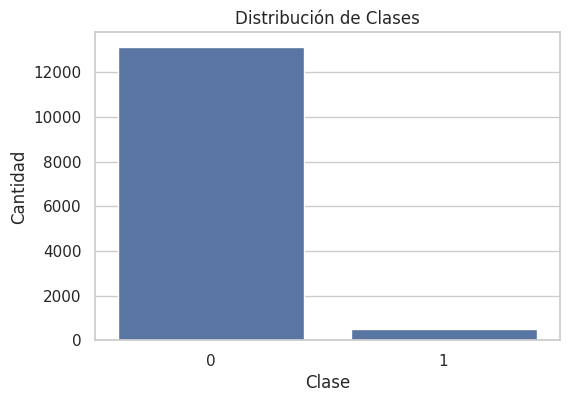

In [13]:
class_counts = y.value_counts()

print(class_counts)
print('\nPorcentaje de clases:')
print(y.value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

Podemos observar que se tiene bastante desbalance, la clase 0 tiene 13137 y la clase 1 tiene  520.

Esto implica que un modelo podria obtener una alta accuracy simplemente prediciendo la clase mayoritaria, sin aprender correctamente los patrones de la clase minoritaria.

**Diagramas KDE para los atributos 5 y 13**

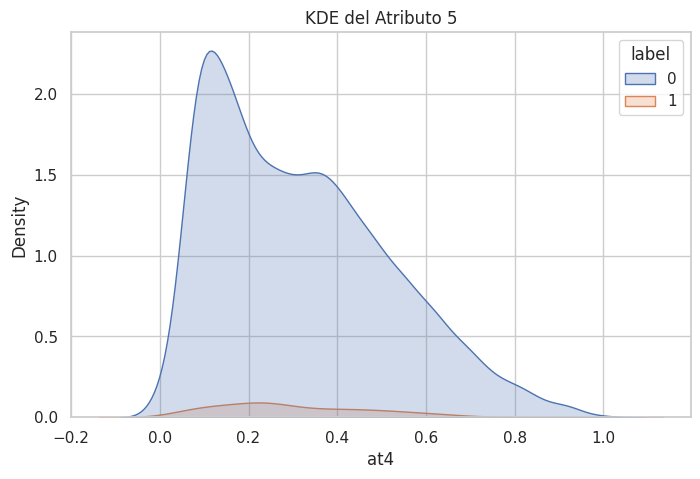

In [19]:
#Para el atributo 5
plt.figure(figsize=(8,5))

sns.kdeplot(data=df, x=df.columns[4], hue='label', fill=True)

plt.title('KDE del Atributo 5')
plt.show()

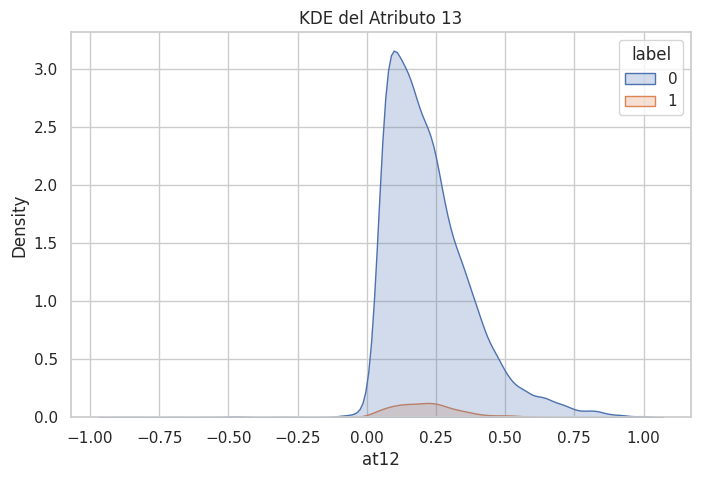

In [18]:
#Para el atributo 13
plt.figure(figsize=(8,5))

sns.kdeplot(data=df, x=df.columns[12], hue='label', fill=True)

plt.title('KDE del Atributo 13')
plt.show()

Nota: Recordemos que existe at0 por lo cual at12 es el 13 y el at4 es el 5.

Los diagramas KDE permiten observar cómo se distribuyen los atributos para cada clase.

En algunos atributos existe traslape considerable entre clases, lo cual puede dificultar la separación mediante un clasificador tradicional.

Además, debido al desbalance, la distribución de la clase minoritaria presenta menor densidad y mayor sensibilidad al ruido.

#Creacion de Modelo Baseline

##**Validacion cruzada estratificada de 5 particiones**

In [20]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

##**Modelo baseline**

In [21]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

El modelo baseline se entrenara sin aplicar tecnicas de balanceo.

##**Metricas de evaluacion**

In [22]:
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

In [23]:
baseline_scores = cross_validate(
    baseline_pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring,
    return_estimator=True
)

print('Accuracy:', baseline_scores['test_accuracy'].mean())
print('Precision:', baseline_scores['test_precision'].mean())
print('Recall:', baseline_scores['test_recall'].mean())
print('F1-score:', baseline_scores['test_f1'].mean())

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.962217219677763
Precision: 0.6
Recall: 0.007692307692307693
F1-score: 0.015166217430368372


Los resultados del modelo baseline muestran claramente el impacto negativo del desbalance de clases sobre el desempeño del clasificador SVM. Aunque el modelo alcanzó una accuracy superior al 96%, las métricas asociadas a la clase minoritaria evidencian un desempeño deficiente.

El recall obtenido fue cercano a cero (0.0077), indicando que el modelo prácticamente no logra detectar los casos positivos reales. Esto demuestra que la alta accuracy es engañosa en escenarios desbalanceados, ya que el clasificador favorece fuertemente la clase mayoritaria.

Además, el warning generado por sklearn indica que en algunos folds de validación cruzada el modelo no realizó predicciones para la clase minoritaria, provocando que la precisión fuera indefinida. Esto confirma que el modelo baseline no es adecuado para resolver correctamente el problema.



**Matriz de confusion**

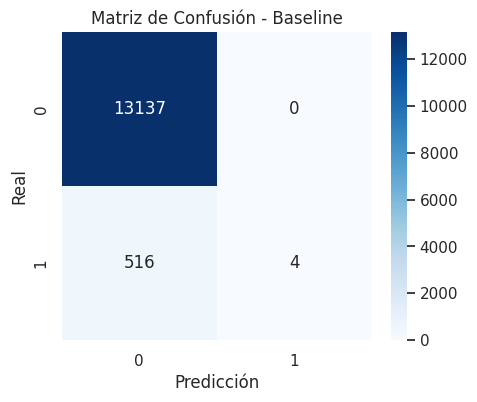

In [24]:
from sklearn.model_selection import cross_val_predict

baseline_predictions = cross_val_predict(
    baseline_pipeline,
    X,
    y,
    cv=skf
)

cm_baseline = confusion_matrix(y, baseline_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Baseline')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [25]:
print(classification_report(y, baseline_predictions))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     13137
           1       1.00      0.01      0.02       520

    accuracy                           0.96     13657
   macro avg       0.98      0.50      0.50     13657
weighted avg       0.96      0.96      0.94     13657



El modelo baseline presenta:

* Accuracy muy alta.
* Recall bajo para la clase minoritaria.
* Dificultad para detectar correctamente los casos positivos.

Esto ocurre porque el modelo está influenciado por la clase mayoritaria.

#**Tratamiento de Clases No Balanceadas**

In [27]:
#Volvemos a observar nuestra distribucion original
print('Distribución original:')
print(y.value_counts())

Distribución original:
label
0    13137
1      520
Name: count, dtype: int64


##**Creacion de modelo con SMOTEENN**

In [28]:
#Aplicacion de smoteenn
smoteenn = SMOTEENN(random_state=42)

X_smoteenn, y_smoteenn = smoteenn.fit_resample(X, y)

print('Distribución después de SMOTEENN:')
print(pd.Series(y_smoteenn).value_counts())

Distribución después de SMOTEENN:
label
1    13080
0    11888
Name: count, dtype: int64


Podemos observar una distribucion mas divida

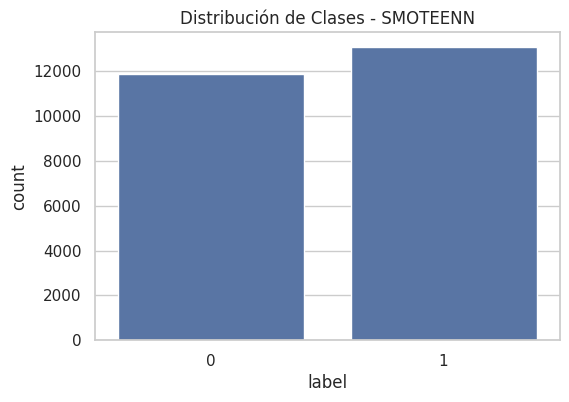

In [30]:
#Visualizacion por clase para ver los resultados de la aplicacion de SMOTEENN
plt.figure(figsize=(6,4))

sns.countplot(x=y_smoteenn)
plt.title('Distribución de Clases - SMOTEENN')
plt.show()

In [31]:
#Armamos pipeline para la evaluacion del modelo
pipeline_smoteenn = ImbPipeline([
    ('balance', SMOTEENN(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

In [32]:
#Evaluacion del modelo con datos smoteenn
scores_smoteenn = cross_validate(
    pipeline_smoteenn,
    X,
    y,
    cv=skf,
    scoring=scoring,
    return_estimator=True
)

print('Accuracy:', scores_smoteenn['test_accuracy'].mean())
print('Precision:', scores_smoteenn['test_precision'].mean())
print('Recall:', scores_smoteenn['test_recall'].mean())
print('F1-score:', scores_smoteenn['test_f1'].mean())

Accuracy: 0.8119649509750048
Precision: 0.14494671099758022
Recall: 0.803846153846154
F1-score: 0.2455686138096667


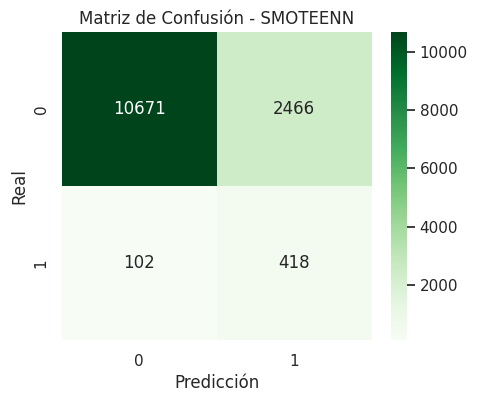

              precision    recall  f1-score   support

           0       0.99      0.81      0.89     13137
           1       0.14      0.80      0.25       520

    accuracy                           0.81     13657
   macro avg       0.57      0.81      0.57     13657
weighted avg       0.96      0.81      0.87     13657



In [33]:
#Matriz de confusion
pred_smoteenn = cross_val_predict(
    pipeline_smoteenn,
    X,
    y,
    cv=skf
)

cm_smoteenn = confusion_matrix(y, pred_smoteenn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_smoteenn, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - SMOTEENN')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

print(classification_report(y, pred_smoteenn))

##**Resultados**

Los resultados obtenidos después de aplicar técnicas de balanceo muestran una mejora significativa en la capacidad del modelo para detectar la clase minoritaria.

El recall de la clase positiva aumentó hasta 0.80, lo que indica que el modelo logra identificar correctamente aproximadamente el 80% de los casos reales de la clase minoritaria. Esto representa una mejora considerable respecto al modelo baseline, donde el recall era prácticamente nulo.

Sin embargo, esta mejora viene acompañada de una disminución en la precisión de la clase minoritaria (0.14). Esto significa que el modelo genera una cantidad importante de falsos positivos, clasificando incorrectamente algunos ejemplos de la clase mayoritaria como positivos.

Asimismo, la accuracy general disminuyó de aproximadamente 96% a 81%. No obstante, esta reducción no implica necesariamente un peor modelo. En problemas de clases desbalanceadas, una alta accuracy puede resultar engañosa, ya que el modelo puede favorecer excesivamente a la clase mayoritaria.

Los resultados muestran que las técnicas de balanceo permiten construir modelos más sensibles a la clase minoritaria, mejorando significativamente el recall y el F1-score. Por ello, métricas como recall y F1-score son más adecuadas que accuracy para evaluar el desempeño real del modelo en este tipo de problemas.

#**Aplicacion de OSS**

In [34]:
oss = OneSidedSelection(random_state=42)

X_oss, y_oss = oss.fit_resample(X, y)

print('Distribución después de OSS:')
print(pd.Series(y_oss).value_counts())

Distribución después de OSS:
label
0    12994
1      520
Name: count, dtype: int64


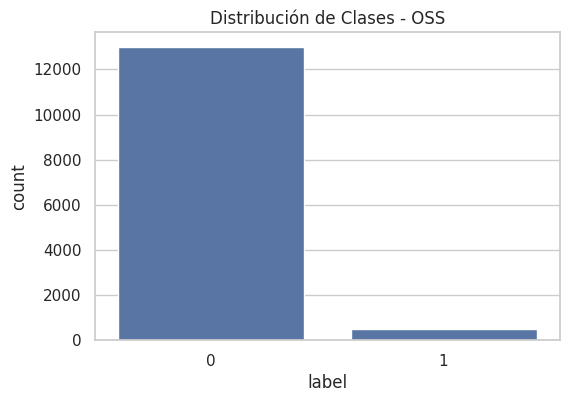

In [35]:
#Visualizacion de la distribucion con aplicacion de oss
plt.figure(figsize=(6,4))

sns.countplot(x=y_oss)
plt.title('Distribución de Clases - OSS')
plt.show()

In [36]:
#Pipeline para la creacion de modelo con datos OSS
pipeline_oss = ImbPipeline([
    ('balance', OneSidedSelection(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

In [37]:
#Evaluacion de modelo con datos oss
scores_oss = cross_validate(
    pipeline_oss,
    X,
    y,
    cv=skf,
    scoring=scoring,
    return_estimator=True
)

print('Accuracy:', scores_oss['test_accuracy'].mean())
print('Precision:', scores_oss['test_precision'].mean())
print('Recall:', scores_oss['test_recall'].mean())
print('F1-score:', scores_oss['test_f1'].mean())

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.962217219677763
Precision: 0.6
Recall: 0.007692307692307693
F1-score: 0.015166217430368372


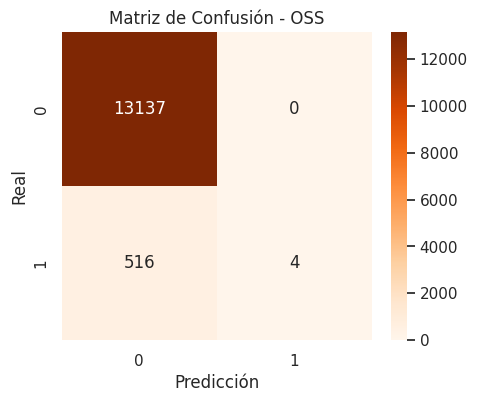

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     13137
           1       1.00      0.01      0.02       520

    accuracy                           0.96     13657
   macro avg       0.98      0.50      0.50     13657
weighted avg       0.96      0.96      0.94     13657



In [38]:
#Visualizacion de matriz de confusion con datos oss
pred_oss = cross_val_predict(
    pipeline_oss,
    X,
    y,
    cv=skf
)

cm_oss = confusion_matrix(y, pred_oss)

plt.figure(figsize=(5,4))
sns.heatmap(cm_oss, annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión - OSS')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()
print(classification_report(y, pred_oss))

##**Resultados de OSS**

Los resultados obtenidos utilizando OSS muestran que esta técnica no logró mejorar significativamente la detección de la clase minoritaria.

Aunque el modelo alcanzó una accuracy cercana al 96% y una precisión de 1.00 para la clase positiva, el recall fue extremadamente bajo (0.01). Esto indica que el clasificador casi nunca predice ejemplos de la clase minoritaria, detectando únicamente alrededor del 1% de los casos positivos reales.

#**Comparacion de resultados de los 3 modelos**

In [39]:
results = pd.DataFrame({
    'Modelo': ['Baseline', 'SMOTEENN', 'OSS'],
    'Accuracy': [
        baseline_scores['test_accuracy'].mean(),
        scores_smoteenn['test_accuracy'].mean(),
        scores_oss['test_accuracy'].mean()
    ],
    'Precision': [
        baseline_scores['test_precision'].mean(),
        scores_smoteenn['test_precision'].mean(),
        scores_oss['test_precision'].mean()
    ],
    'Recall': [
        baseline_scores['test_recall'].mean(),
        scores_smoteenn['test_recall'].mean(),
        scores_oss['test_recall'].mean()
    ],'F1-score': [
        baseline_scores['test_f1'].mean(),
        scores_smoteenn['test_f1'].mean(),
        scores_oss['test_f1'].mean()
    ]
})

results

,Modelo,Accuracy,Precision,Recall,F1-score
0,Baseline,0.962217,0.600000,0.007692,0.015166
1,SMOTEENN,0.811965,0.144947,0.803846,0.245569
2,OSS,0.962217,0.600000,0.007692,0.015166


##**Grafica comparativa**

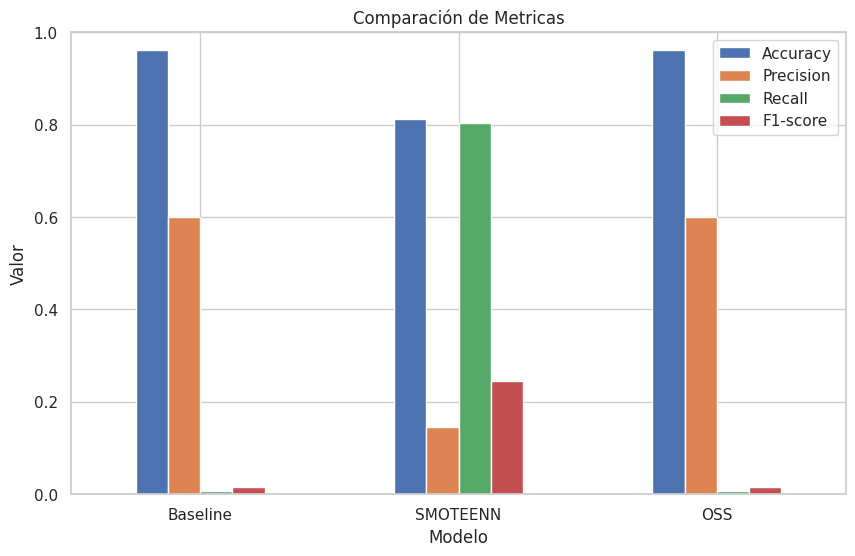

In [40]:
results_plot = results.set_index('Modelo')

results_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Comparación de Metricas')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

¿Es suficiente Accuracy?

No.

En problemas con clases desbalanceadas, Accuracy puede resultar engañosa.

Por ejemplo, un modelo que predice siempre la clase mayoritaria fallaría completamente en detectar la clase minoritaria.

Por ello, metricas como:

* Recall
* Precision
* F1-score

son más apropiadas para evaluar el desempeño real del modelo.

Impacto del Desbalance

El desbalance provoca que el modelo:

* Aprenda principalmente patrones de la clase mayoritaria.
* Ignore parcialmente la clase minoritaria.
* Tenga bajo recall para los casos positivos.

Esto es problematico cuando la clase minoritaria representa eventos importantes.

**Diferencias entre SMOTEENN y OSS**

SMOTEENN

Combina:

Oversampling sintético mediante SMOTE.
Limpieza de ruido mediante Edited Nearest Neighbors.

Ventajas:

Mejora significativamente el recall.
Genera ejemplos sintéticos útiles.
Reduce ruido después del oversampling.

Desventajas:

Puede introducir algo de sobreajuste.
Incrementa el tiempo de entrenamiento.
One-Sided Selection (OSS)

OSS elimina ejemplos redundantes de la clase mayoritaria.

Ventajas:

Reduce tamaño del dataset.
Elimina ejemplos

#**Resultados y conclusion final**

De los tres modelos evaluados, SMOTEENN fue el método que obtuvo los mejores resultados para el problema de clasificación desbalanceada.

Aunque presentó una accuracy menor en comparación con el baseline y OSS, logró incrementar significativamente el recall de la clase minoritaria, alcanzando un valor cercano al 80%. Esto indica que el modelo fue capaz de detectar correctamente la mayoría de los casos positivos reales.

Además, SMOTEENN obtuvo el mayor F1-score, demostrando un mejor equilibrio entre precisión y recall. En contraste, tanto el modelo baseline como OSS mostraron un recall extremadamente bajo, evidenciando que prácticamente ignoraban la clase minoritaria.

Los resultados también muestran que accuracy no es una métrica suficiente para evaluar problemas desbalanceados. Tanto el baseline como OSS alcanzaron más del 96% de accuracy, pero fallaron casi completamente en la detección de la clase positiva.

En conclusión, SMOTEENN resultó ser la técnica más efectiva para este conjunto de datos, ya que permitió construir un modelo más sensible a la clase minoritaria y con un desempeño más representativo del problema real de clasificación.